In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import nibabel as nib
import random
import SimpleITK as sitk

In [6]:
patient_data = pd.read_csv("patient_data.csv")

In [4]:
patient_data.iloc[:6,]

,patient_id,age,gender,phase,cancer_type,ct_path,mask_path,liver_mask_path
0,P0001,58.0,male,P,HCC,ct_files/P0001_ct_P.nii.gz,mask_files/P0001_mask_P.nii.gz,liver_mask_files/P0001-livermask_P.nii.gz
1,P0001,58.0,male,C3,HCC,ct_files/P0001_ct_C3.nii.gz,mask_files/P0001_mask_C3.nii.gz,liver_mask_files/P0001-livermask_C3.nii.gz
2,P0001,58.0,male,C2,HCC,ct_files/P0001_ct_C2.nii.gz,mask_files/P0001_mask_C2.nii.gz,liver_mask_files/P0001-livermask_C2.nii.gz
3,P0001,58.0,male,C1,HCC,ct_files/P0001_ct_C1.nii.gz,mask_files/P0001_mask_C1.nii.gz,liver_mask_files/P0001-livermask_C1.nii.gz
4,P0002,70.0,male,C2,HCC,ct_files/P0002_ct_C2.nii.gz,mask_files/P0002_mask_C2.nii.gz,liver_mask_files/P0002-livermask_C2.nii.gz
5,P0002,70.0,male,C3,HCC,ct_files/P0002_ct_C3.nii.gz,mask_files/P0002_mask_C3.nii.gz,liver_mask_files/P0002-livermask_C3.nii.gz


In [8]:
# Đường dẫn gốc đến thư mục dữ liệu
root_folder_path = "../NCKH"  # <-- Điều chỉnh nếu cần


# Chọn bệnh nhân và giai đoạn
patient_id = 'P0059'  # có thể thay bằng ID trong file của bạn, ví dụ: 'P0001'
stage = 'C1'          # có thể là 'P', 'C1', 'C2', 'C3'

# Lọc ra dòng tương ứng
selected_row = patient_data[(patient_data['patient_id'] == patient_id) & 
                            (patient_data['phase'] == stage)].iloc[0]

# Đọc ảnh CT gan
ct_file_path = os.path.join(root_folder_path, selected_row['ct_path'])
liver_image = sitk.ReadImage(ct_file_path, sitk.sitkInt16)
liver_image_array = sitk.GetArrayFromImage(liver_image)

# Đọc liver mask
liver_mask_path = os.path.join(root_folder_path, selected_row['liver_mask_path'])
liver_mask = sitk.ReadImage(liver_mask_path, sitk.sitkUInt8)
liver_mask_array = sitk.GetArrayFromImage(liver_mask)

# Đọc lesion mask nếu có
if pd.notna(selected_row['mask_path']):
    mask_path = os.path.join(root_folder_path, selected_row['mask_path'])
    mask = sitk.ReadImage(mask_path, sitk.sitkUInt8)
    mask_array = sitk.GetArrayFromImage(mask)
else:
    mask_array = None  # Không có mask tổn thương


In [10]:
image = sitk.ReadImage("ct_files/P0001_ct_C1.nii.gz")
array = sitk.GetArrayFromImage(image)
print(array.shape)


(74, 512, 512)


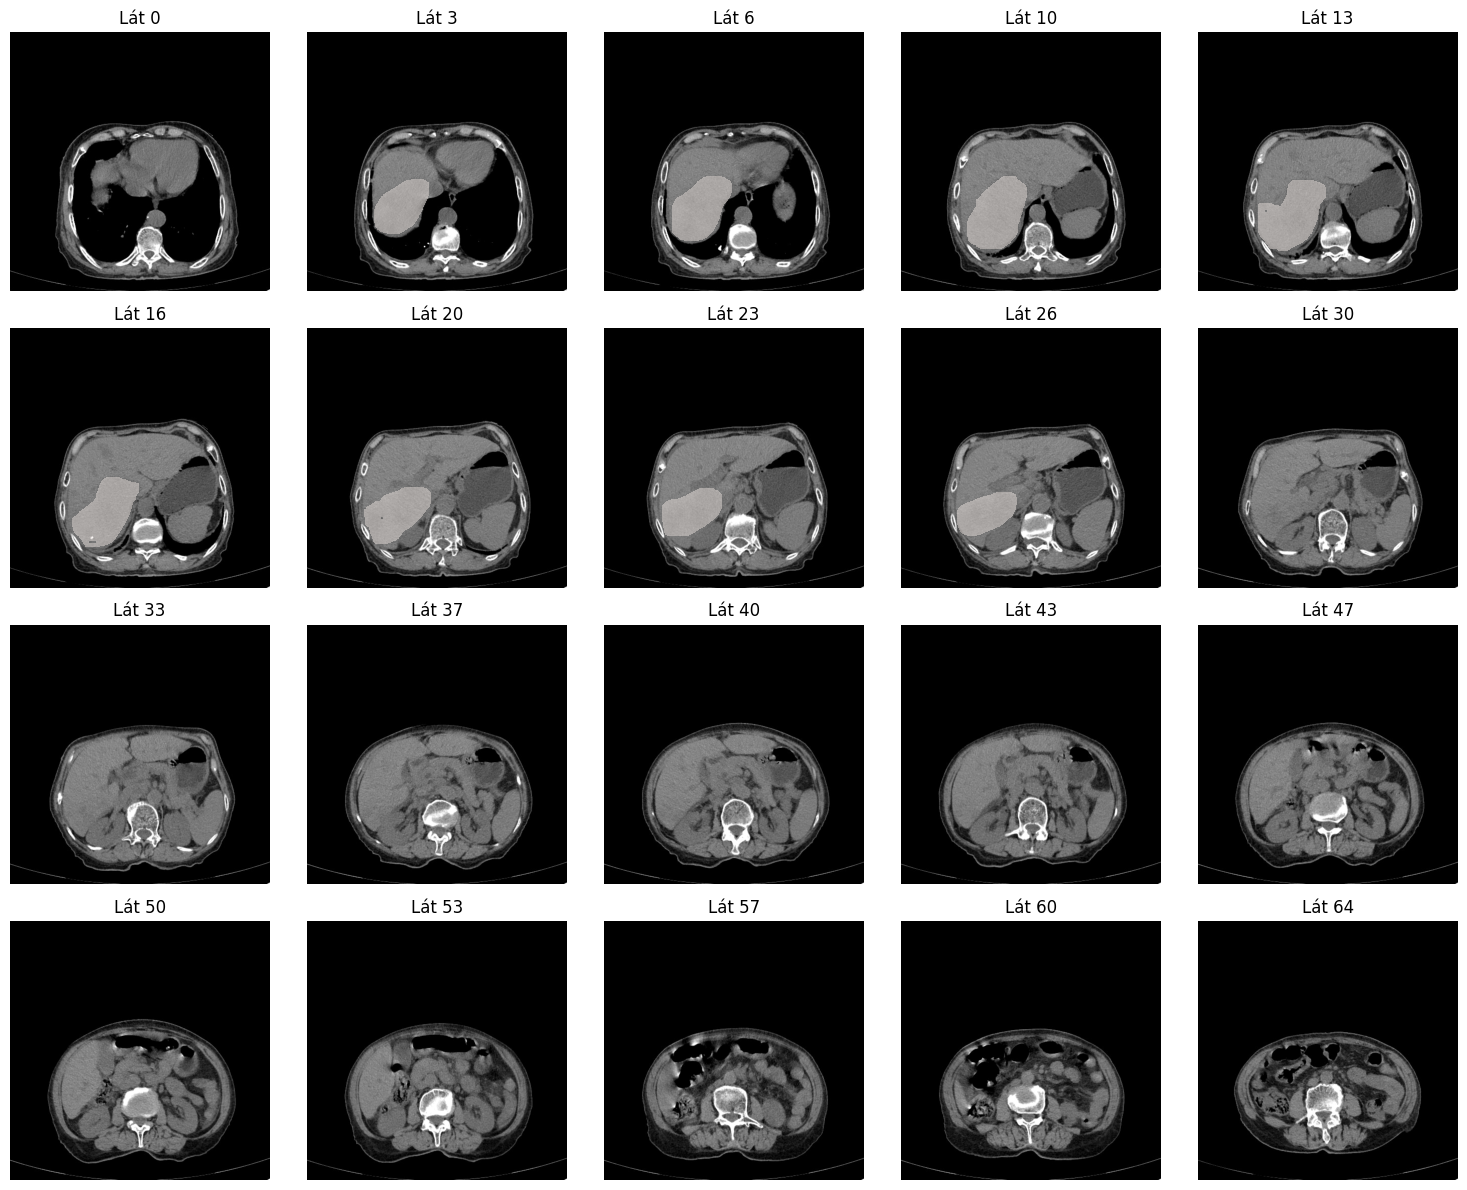

In [13]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
import os

# Đường dẫn đến ảnh và mask
ct_path = "ct_files/P0001_ct_P.nii.gz"
mask_path = "mask_files/P0001_mask_P.nii.gz"  # Nếu không có mask thì đặt None

# Đọc CT ảnh
ct_image = sitk.ReadImage(ct_path)
ct_array = sitk.GetArrayFromImage(ct_image)

# Đọc mask nếu có
mask_array = None
if mask_path and os.path.exists(mask_path):
    mask_image = sitk.ReadImage(mask_path)
    mask_array = sitk.GetArrayFromImage(mask_image)

# Hiển thị 20 lát ảnh cách đều nhau
total_slices = ct_array.shape[0]
slice_indices = np.linspace(0, total_slices - 1, 20, dtype=int)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

for i, idx in enumerate(slice_indices):
    axes[i].imshow(ct_array[idx], cmap='gray')
    if mask_array is not None:
        # overlay mask bằng màu đỏ (độ trong suốt alpha=0.4)
        mask_slice = mask_array[idx]
        axes[i].imshow(np.ma.masked_where(mask_slice == 0, mask_slice), cmap='Reds', alpha=0.4)
    axes[i].set_title(f"Lát {idx}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


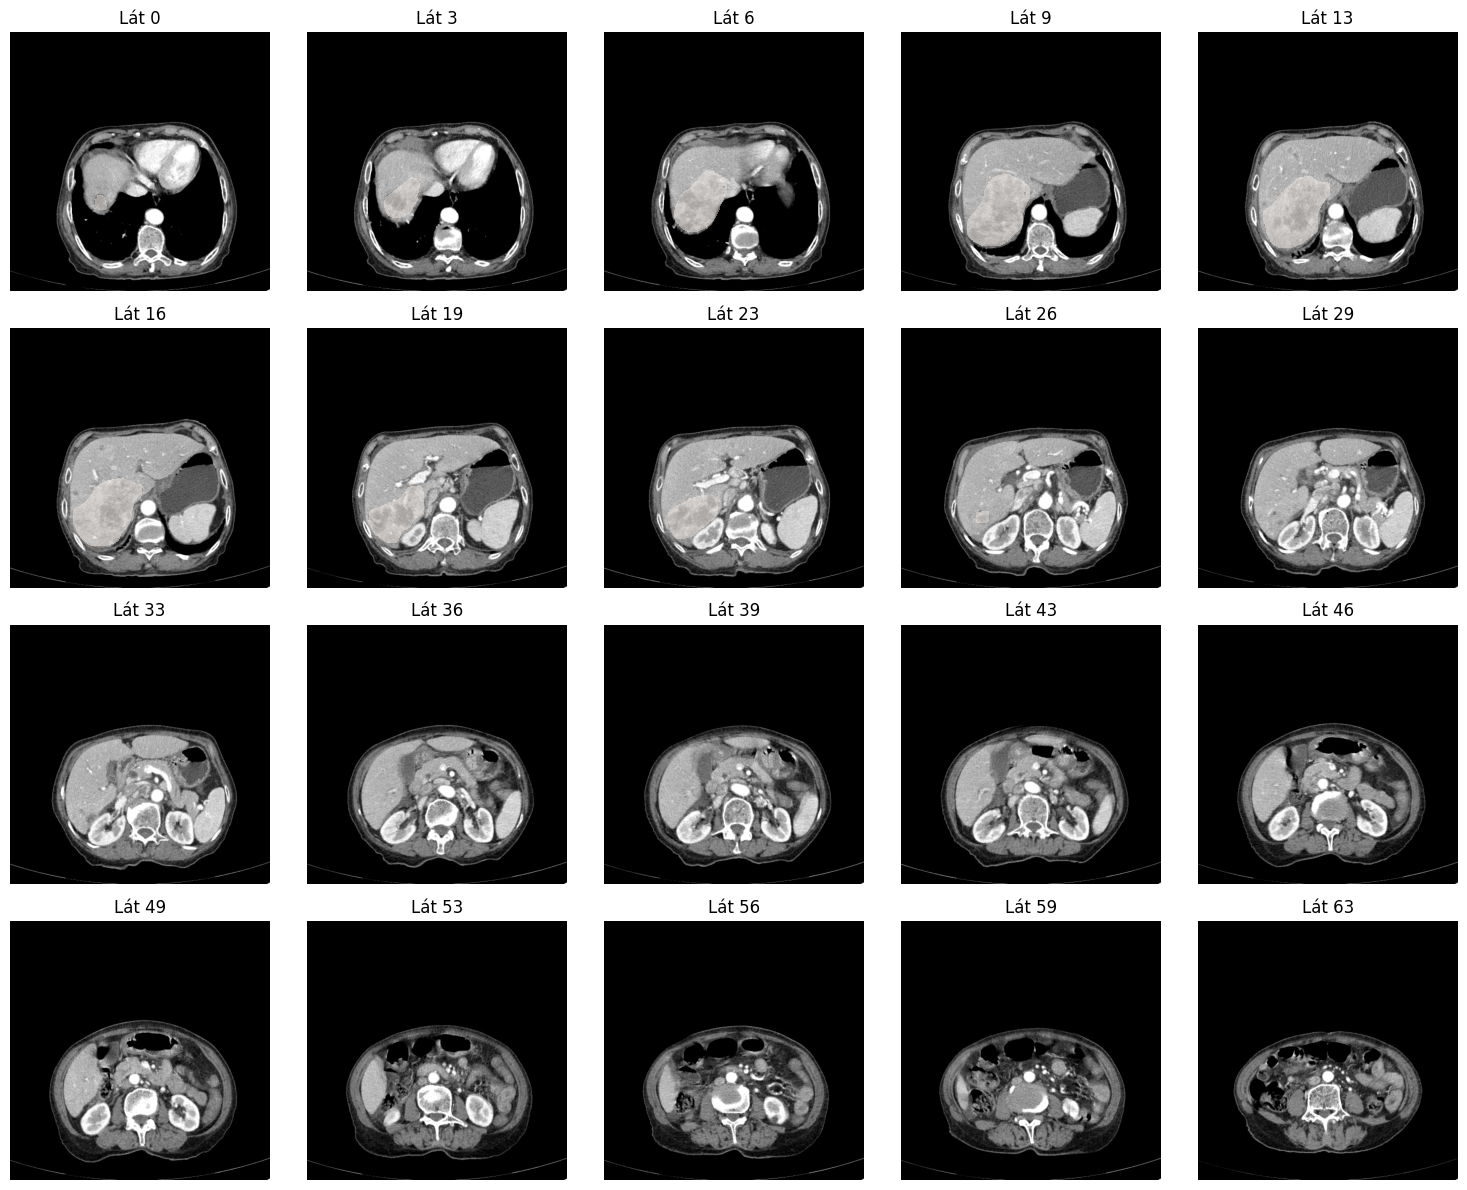

In [12]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
import os

# Đường dẫn đến ảnh và mask
ct_path = "ct_files/P0001_ct_C2.nii.gz"
mask_path = "mask_files/P0001_mask_C2.nii.gz"  # Nếu không có mask thì đặt None

# Đọc CT ảnh
ct_image = sitk.ReadImage(ct_path)
ct_array = sitk.GetArrayFromImage(ct_image)

# Đọc mask nếu có
mask_array = None
if mask_path and os.path.exists(mask_path):
    mask_image = sitk.ReadImage(mask_path)
    mask_array = sitk.GetArrayFromImage(mask_image)

# Hiển thị 20 lát ảnh cách đều nhau
total_slices = ct_array.shape[0]
slice_indices = np.linspace(0, total_slices - 1, 20, dtype=int)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

for i, idx in enumerate(slice_indices):
    axes[i].imshow(ct_array[idx], cmap='gray')
    if mask_array is not None:
        # overlay mask bằng màu đỏ (độ trong suốt alpha=0.4)
        mask_slice = mask_array[idx]
        axes[i].imshow(np.ma.masked_where(mask_slice == 0, mask_slice), cmap='Reds', alpha=0.4)
    axes[i].set_title(f"Lát {idx}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


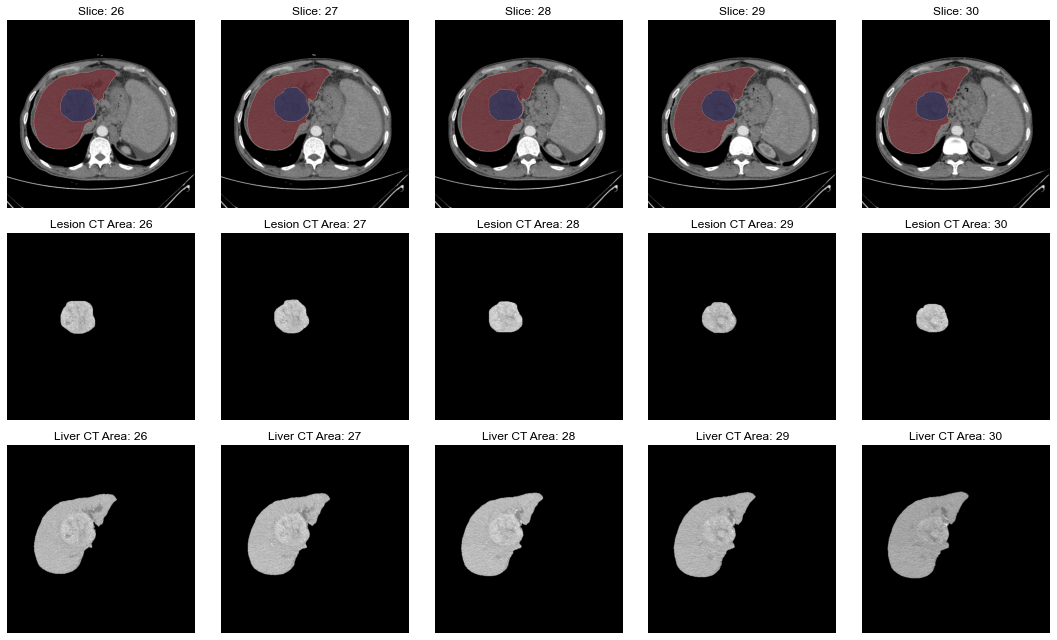

In [12]:
# 随机选择连续的5个有病灶的层
num_slices = liver_image_array.shape[0]  # 使用array的shape而不是Image对象的shape
# 如果 mask_array 为 None，则不执行找病灶层的操作
if mask_array is not None:
    # 找到所有有病灶的层
    mask_slices = [i for i in range(num_slices) if np.any(mask_array[i, :, :] > 0)]
    # 从有病灶的层中随机选择一个起始点
    if len(mask_slices) > 4:
        start_slice = random.choice(range(len(mask_slices) - 4))
        # 选择连续的5个层
        random_slices = mask_slices[start_slice:start_slice + 5]
    else:
        random_slices = []
else:
    random_slices = []

# 创建子图
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
plt.rcParams['font.family'] = 'Arial'  # 设置字体为Arial

for i, slice_index in enumerate(random_slices):
    # 展示图像，使用正确的切片索引
    axes[0, i].imshow(liver_image_array[slice_index, :, :], cmap='gray')  
    axes[0, i].set_title(f'Slice: {slice_index}')
    axes[0, i].axis('off')
    
    # 在原图上叠加肝脏mask，使用红色透明层
    liver_mask_slice_data = liver_mask_array[slice_index, :, :]
    liver_alpha = np.where(liver_mask_slice_data > 0, 0.5, 0)
    axes[0, i].imshow(liver_mask_slice_data, cmap='Reds', alpha=liver_alpha)
    
    # 如果存在病灶mask，则在同一图中叠加病灶mask，使用蓝色透明层
    if mask_array is not None:
        mask_slice_data = mask_array[slice_index, :, :]
        mask_alpha = np.where(mask_slice_data > 0, 0.5, 0)
        axes[0, i].imshow(mask_slice_data, cmap='Blues', alpha=mask_alpha)
    
    # 如果存在病灶mask，则展示病灶mask对应的原CT图像区域
    if mask_array is not None:
        ct_slice_data = liver_image_array[slice_index, :, :]
        mask_slice_data = mask_array[slice_index, :, :]
        ct_masked_slice = np.where(mask_slice_data > 0, ct_slice_data, 0)
        axes[1, i].imshow(ct_masked_slice, cmap='gray')
        axes[1, i].set_title(f'Lesion CT Area: {slice_index}')
        axes[1, i].axis('off')

    # 展示肝脏mask对应的原CT图像区域
    liver_ct_slice_data = liver_image_array[slice_index, :, :]
    liver_mask_slice_data = liver_mask_array[slice_index, :, :]
    liver_ct_masked_slice = np.where(liver_mask_slice_data > 0, liver_ct_slice_data, 0)
    axes[2, i].imshow(liver_ct_masked_slice, cmap='gray')
    axes[2, i].set_title(f'Liver CT Area: {slice_index}')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()